## Getting the data

Request all issues with personified token from github_apikey.key file. One can generate a token under https://github.com/settings/tokens

Downloaded data available on https://gigamove.rwth-aachen.de/de/download/5726f0a388b74818ddd8fdec187bd267

In [1]:
import requests
import pandas as pd
import time
import os

In [2]:
TOKEN = "YOUR_PERSONAL_ACCESS_TOKEN" 
if os.path.exists("github_apikey.key"):
    with open("github_apikey.key", 'r') as f:
        TOKEN = f.read().replace("\n", "")

OWNER = "tensorflow"
REPO = "tensorflow"

query_template = """
query($cursor: String) {
  rateLimit {
    cost
    remaining
    resetAt
  }
  repository(owner: "%s", name: "%s") {
    issues(
      states: CLOSED, 
      first: 30, 
      after: $cursor
    ) {
      pageInfo {
        hasNextPage
        endCursor
      }
      nodes {
        number
        title
        body
        createdAt
        author {
          login
        }
        labels(first: 20) {
          nodes {
            name
          }
        }
        comments(first: 100) {
          nodes {
            author {
              login
            }
            body
          }
        }
      }
    }
  }
}
"""


In [3]:
def run_query(owner, repo, cursor):
    url = 'https://api.github.com/graphql'
    headers = {"Authorization": f"Bearer {TOKEN}"}
    variables = {"cursor": cursor}
    
    try:
        response = requests.post(url, json={'query': query_template % (owner, repo), 'variables': variables}, headers=headers, timeout=30)
        if response.status_code == 200:
            return response.json()
        else:
            print(f"Error {response.status_code}: {response.text}")
            return None
    except Exception as e:
        print(f"Connection Error: {e}")
        return None

In [4]:
def request_all_issues(owner, repo):
    has_next = True
    cursor = None
    total_issues_processed = 0

    raw_data = open("raw_data_"+repo+".txt", 'w', encoding='utf-8')

    while has_next:
        result = run_query(owner, repo, cursor)
        
        # Check for empty result or connection failure
        if not result:
            print("Network error. Sleeping 5s...")
            time.sleep(5)
            continue

        # Check for GraphQL specific errors (e.g., Bad syntax)
        if 'errors' in result:
            print(f"GraphQL Error: {result['errors']}")
            break # Break loop, otherwise it retries infinitely

        # Check if data exists
        if 'data' not in result or not result['data']:
            print("No data returned.")
            break
        
        data = result['data']
        
        if 'rateLimit' in data:
            rate_limit = data['rateLimit']
            remaining = rate_limit['remaining']
            print(f"Points remaining: {remaining} (Cost: {rate_limit['cost']})")
            
            if remaining < 100:
                print("RATE LIMIT NEAR! Sleeping for 1 hour...")
                time.sleep(3600)
        
        data_repo = data['repository']['issues']
        
        for issue in data_repo['nodes']:
            if not issue or not issue['author'] or not issue['title'] or not issue['body']: 
                continue
            
            issue_id = str(issue['number'])
            issue_author = issue['author']['login']

            issue_title = issue['title'].replace("\n", " ").replace("\r", "")
            issue_body = issue['body'].replace("\n", " ").replace("\r", "")
            issue_date = issue['createdAt']

            label_list = []
            if 'labels' in issue and issue['labels']['nodes']:
                label_list = [l['name'] for l in issue['labels']['nodes']]
            
            label_str = "|".join(label_list)

            raw_data.write(f"issue:{issue_author}\n{label_str}\n{issue_date}\n{issue_title}\n{issue_body}\n")

            if 'comments' in issue and issue['comments']['nodes']:
                for comment in issue['comments']['nodes']:
                    if not comment or not comment['author'] or not comment['body']: 
                        continue
                    
                    comment_author = comment['author']['login']
                    
                    comment_body = comment['body'].replace("\n", " ").replace("\r", "")

                    raw_data.write(f"comment:{comment_author}\n{comment_body}\n")

        # Update Progress
        total_issues_processed += len(data_repo['nodes'])
        has_next = data_repo['pageInfo']['hasNextPage']
        cursor = data_repo['pageInfo']['endCursor']
        
        print(f"Total issues saved: {total_issues_processed}")

    raw_data.close()
    print("Done")

In [5]:
request_all_issues("networkx", "networkx")

Points remaining: 4999 (Cost: 1)
Total issues saved: 30
Points remaining: 4998 (Cost: 1)
Total issues saved: 60
Points remaining: 4997 (Cost: 1)
Total issues saved: 90
Points remaining: 4996 (Cost: 1)
Total issues saved: 120
Points remaining: 4995 (Cost: 1)
Total issues saved: 150
Points remaining: 4994 (Cost: 1)
Total issues saved: 180
Points remaining: 4993 (Cost: 1)
Total issues saved: 210
Points remaining: 4992 (Cost: 1)
Total issues saved: 240
Points remaining: 4991 (Cost: 1)
Total issues saved: 270
Points remaining: 4990 (Cost: 1)
Total issues saved: 300
Points remaining: 4989 (Cost: 1)
Total issues saved: 330
Points remaining: 4988 (Cost: 1)
Total issues saved: 360
Points remaining: 4987 (Cost: 1)
Total issues saved: 390
Points remaining: 4986 (Cost: 1)
Total issues saved: 420
Points remaining: 4985 (Cost: 1)
Total issues saved: 450
Points remaining: 4984 (Cost: 1)
Total issues saved: 480
Points remaining: 4983 (Cost: 1)
Total issues saved: 510
Points remaining: 4982 (Cost: 1)
T

In [6]:
request_all_issues("pandas-dev", "pandas")

Points remaining: 4893 (Cost: 1)
Total issues saved: 30
Points remaining: 4892 (Cost: 1)
Total issues saved: 60
Points remaining: 4891 (Cost: 1)
Total issues saved: 90
Points remaining: 4890 (Cost: 1)
Total issues saved: 120
Points remaining: 4889 (Cost: 1)
Total issues saved: 150
Points remaining: 4888 (Cost: 1)
Total issues saved: 180
Points remaining: 4887 (Cost: 1)
Total issues saved: 210
Points remaining: 4886 (Cost: 1)
Total issues saved: 240
Points remaining: 4885 (Cost: 1)
Total issues saved: 270
Points remaining: 4884 (Cost: 1)
Total issues saved: 300
Points remaining: 4883 (Cost: 1)
Total issues saved: 330
Points remaining: 4882 (Cost: 1)
Total issues saved: 360
Points remaining: 4881 (Cost: 1)
Total issues saved: 390
Points remaining: 4880 (Cost: 1)
Total issues saved: 420
Points remaining: 4879 (Cost: 1)
Total issues saved: 450
Points remaining: 4878 (Cost: 1)
Total issues saved: 480
Points remaining: 4877 (Cost: 1)
Total issues saved: 510
Points remaining: 4876 (Cost: 1)
T

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import os

read_raw_data = open("raw_data_tensorflow.txt", 'r', encoding='utf-8')

G = nx.DiGraph()

current_issue_opener = ""

for line in read_raw_data:
    if line.startswith("issue:"):
        current_issue_opener = line.strip().split(':')[1]
    elif line.startswith("comment:"):
        commentor = line.strip().split(':')[1]
        if commentor != current_issue_opener: 
            G.add_edge(commentor, current_issue_opener)

print(G)

DiGraph with 42897 nodes and 112810 edges


In [24]:
largest = max(nx.weakly_connected_components(G), key=len)

G = G.subgraph(largest)

print("G is a " + str(G))

G is a DiGraph with 42785 nodes and 112749 edges


In [25]:
in_degree_sequence = sorted([d for d in G.in_degree()], key = (lambda x: x[1]), reverse=True)

out_degree_sequence = sorted([d for d in G.out_degree()], key = (lambda x: x[1]), reverse=True)

print(in_degree_sequence[0:10])
print(out_degree_sequence[0:10])

[('yaroslavvb', 222), ('cancan101', 189), ('ppwwyyxx', 174), ('alanpurple', 146), ('dynamicwebpaige', 137), ('lgeiger', 118), ('jiapei100', 113), ('Hvass-Labs', 110), ('mrry', 106), ('bhack', 102)]
[('google-ml-butler', 9979), ('tensorflowbutler', 3513), ('github-actions', 2662), ('tilakrayal', 2123), ('ymodak', 2100), ('Saduf2019', 2044), ('jvishnuvardhan', 1936), ('tensorflow-bot', 1884), ('ravikyram', 1774), ('sushreebarsa', 1683)]


In [26]:
print(in_degree_sequence[int(len(in_degree_sequence)/2)])

('Theresaliu', 1)


In [27]:
print(out_degree_sequence[int(len(out_degree_sequence)/2)])

('miltonlopezjr', 1)


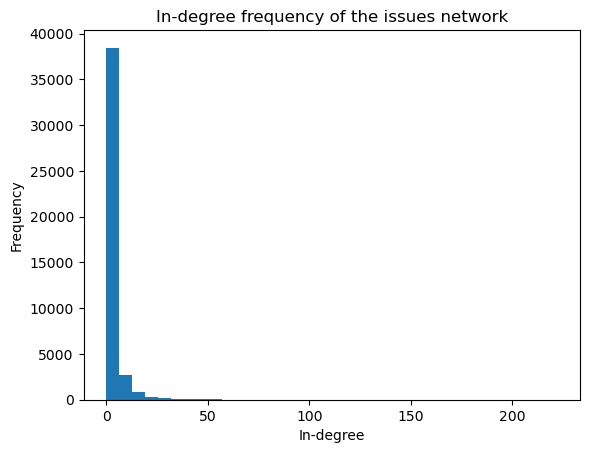

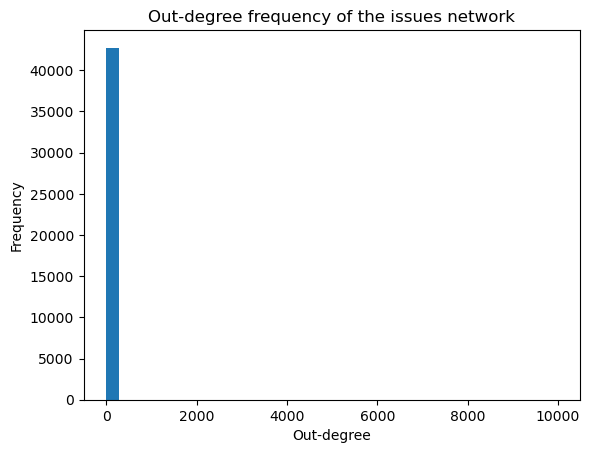

In [28]:
in_degree_sequence = sorted([d for d in G.in_degree()], key = (lambda x: x[1]))
out_degree_sequence = sorted([d for d in G.out_degree()], key = (lambda x: x[1]))

number_bins = 35

plt.hist([x[1] for x in in_degree_sequence], bins=number_bins)
plt.xlabel("In-degree")
plt.ylabel("Frequency")
plt.title("In-degree frequency of the issues network")
plt.show()

plt.hist([x[1] for x in out_degree_sequence], bins=number_bins)
plt.xlabel("Out-degree")
plt.ylabel("Frequency")
plt.title("Out-degree frequency of the issues network")
plt.show()

In [29]:
G_mod = nx.DiGraph(G)

for (user, number_nodes) in in_degree_sequence:
    if number_nodes == 0:
        G_mod.remove_node(user)

print(G)

DiGraph with 42785 nodes and 112749 edges


In [30]:
print(G_mod)

DiGraph with 21540 nodes and 48693 edges


In [31]:
for (user, number_nodes) in out_degree_sequence:
    if number_nodes == 0:
        G_mod.remove_node(user)

print(G)
print(G_mod)

DiGraph with 42785 nodes and 112749 edges
DiGraph with 6232 nodes and 23430 edges


In [35]:
largest = max(nx.weakly_connected_components(G_mod), key=len)

G_mod = G_mod.subgraph(largest)

print("G is a " + str(G_mod))

G is a DiGraph with 5919 nodes and 23423 edges


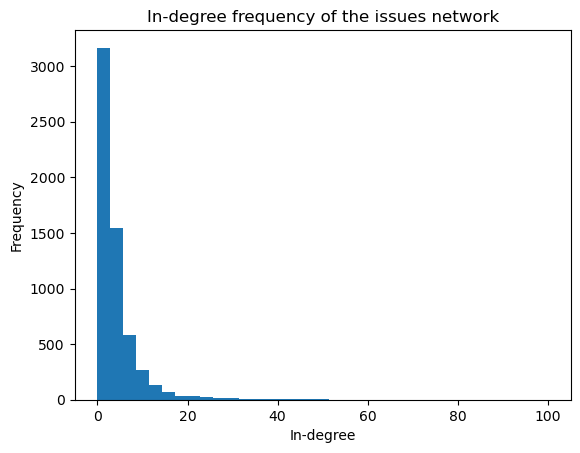

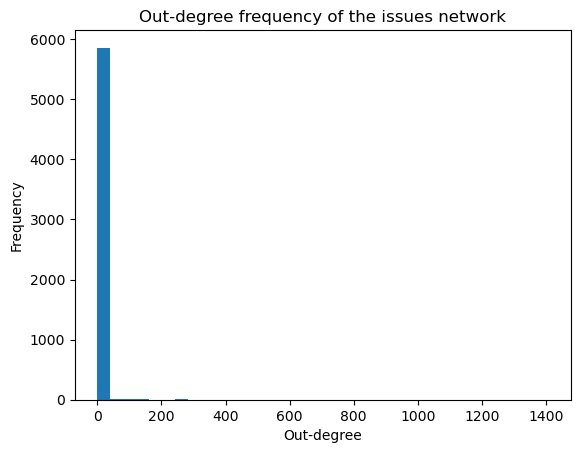

In [36]:
in_degree_sequence = sorted([d for d in G_mod.in_degree()], key = (lambda x: x[1]))
out_degree_sequence = sorted([d for d in G_mod.out_degree()], key = (lambda x: x[1]))

number_bins = 35

plt.hist([x[1] for x in in_degree_sequence], bins=number_bins)
plt.xlabel("In-degree")
plt.ylabel("Frequency")
plt.title("In-degree frequency of the issues network")
plt.show()

plt.hist([x[1] for x in out_degree_sequence], bins=number_bins)
plt.xlabel("Out-degree")
plt.ylabel("Frequency")
plt.title("Out-degree frequency of the issues network")
plt.show()

In [33]:
G_und = G_mod.to_undirected()

pose = nx.forceatlas2_layout(G_und)

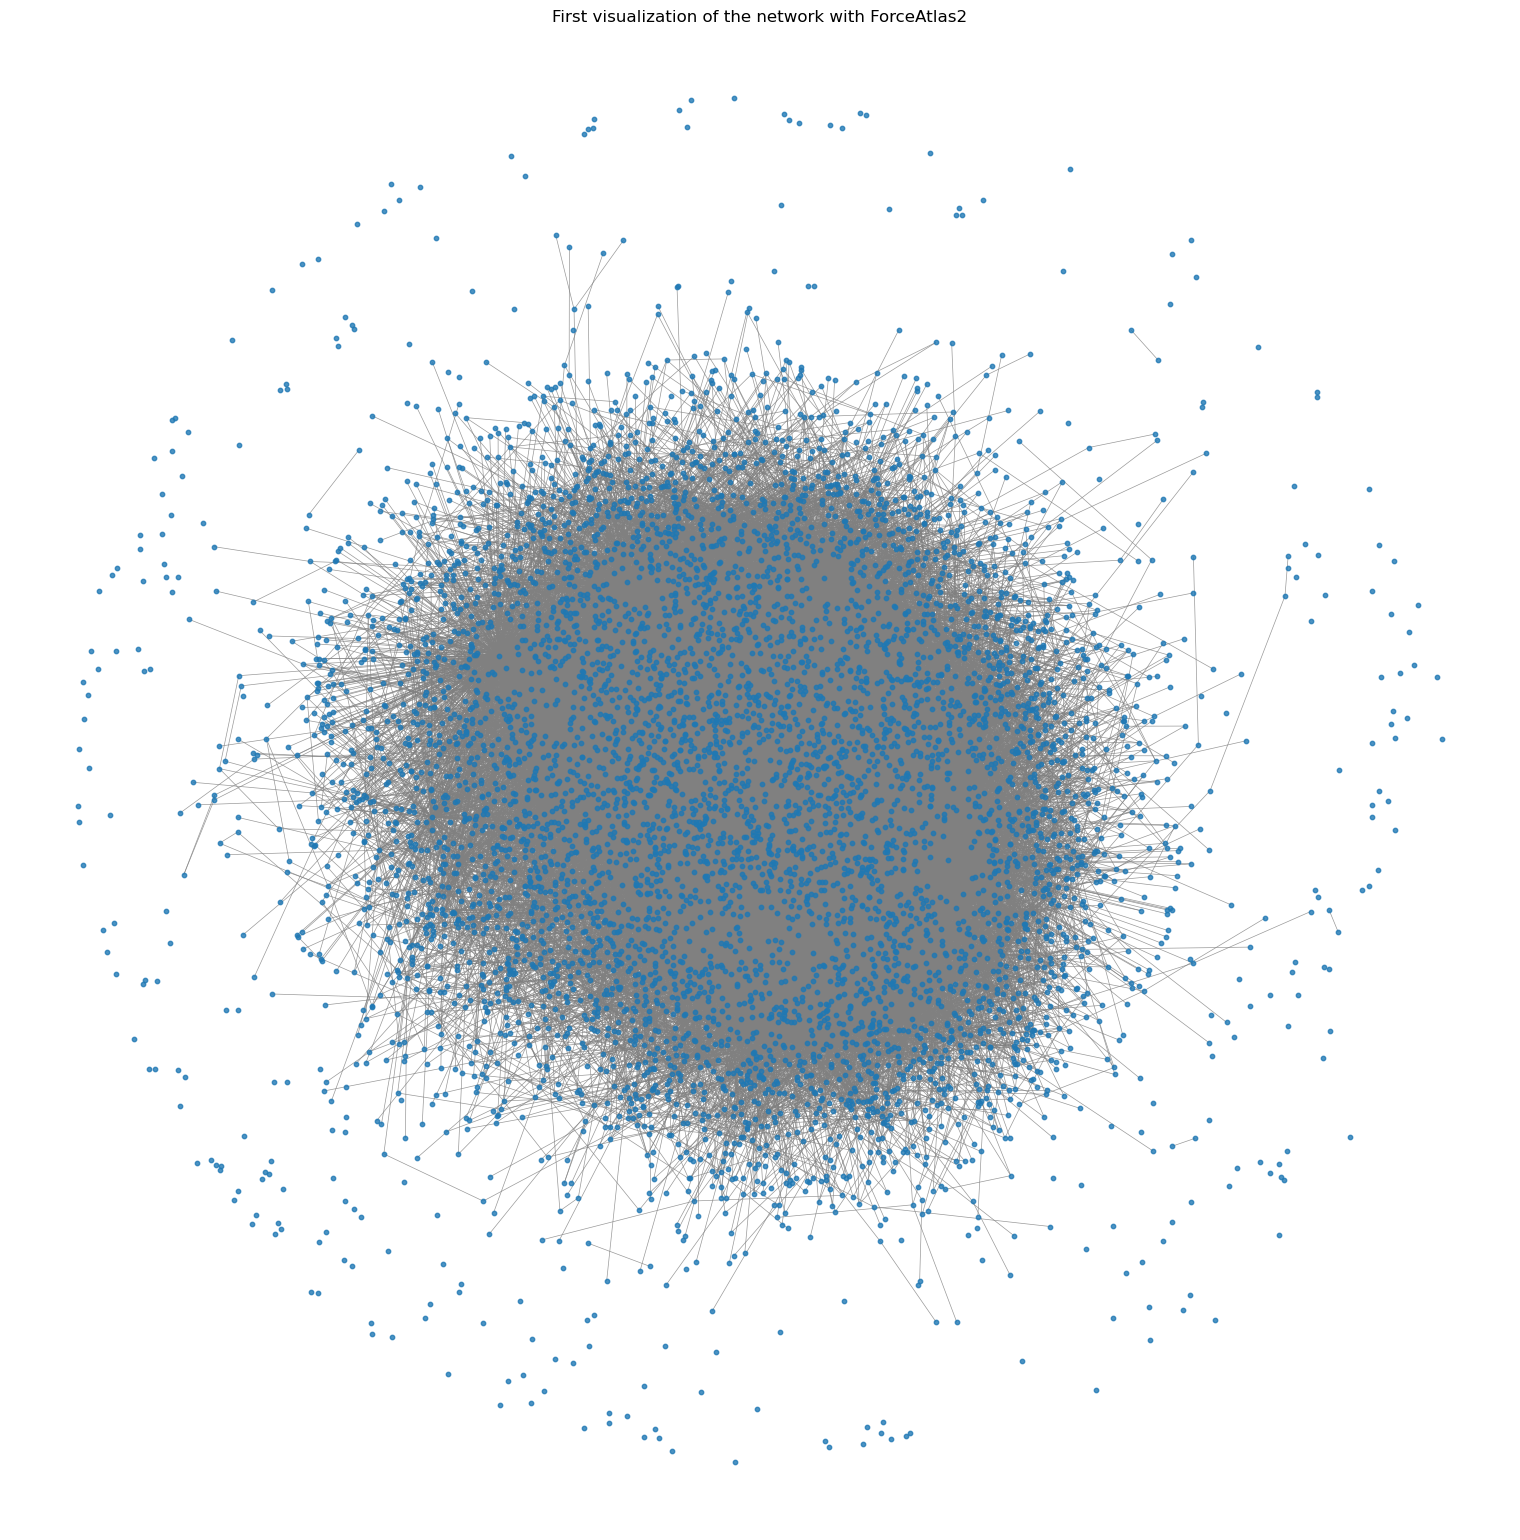

In [34]:
plt.figure(figsize=(15, 15))

nx.draw(
    G_und,
    pos=pose,
    node_size=10,
    alpha=0.8,
    edge_color='gray',
    width=0.5,
    with_labels=False
)

plt.title("First visualization of the network with ForceAtlas2")
plt.axis('off')
plt.show()

75


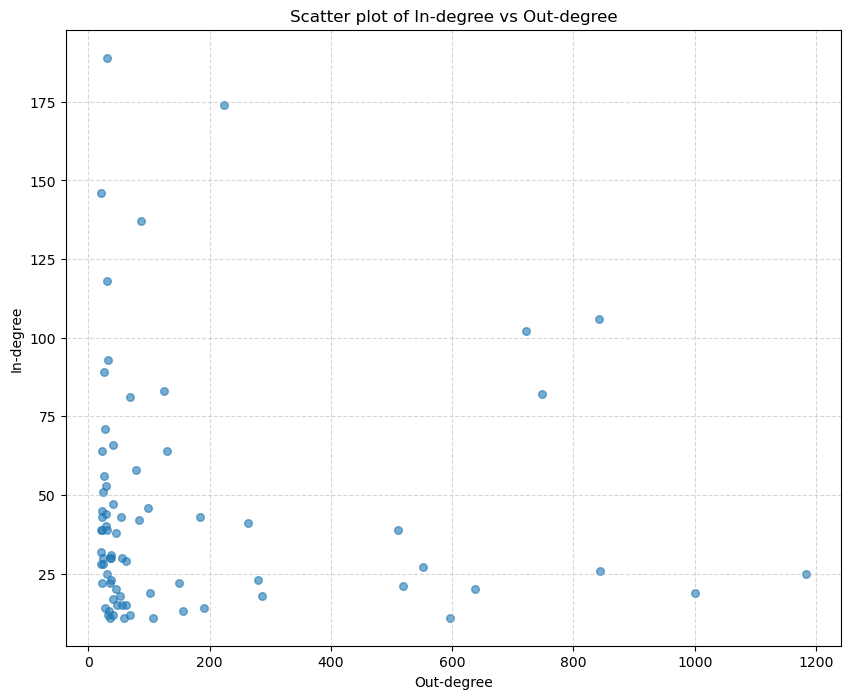

In [43]:
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

nodes = list(G.nodes())
x_out = [out_degrees[n] for n in nodes if out_degrees[n] < 1500 and in_degrees[n] < 200 and out_degrees[n] > 20 and in_degrees[n] > 10]
y_in  = [in_degrees[n] for n in nodes if in_degrees[n] < 200 and out_degrees[n] < 1500 and out_degrees[n] > 20 and in_degrees[n] > 10]

print(len(x_out))

plt.figure(figsize=(10, 8))
plt.scatter(x_out, y_in, alpha=0.6, s=30)

plt.xlabel("Out-degree")
plt.ylabel("In-degree")
plt.title("Scatter plot of In-degree vs Out-degree")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
import re
import ast
import random
import statistics
import math
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path
from typing import List, Dict, Optional
from collections import Counter, defaultdict

In [3]:
G_weighted = nx.DiGraph()

read_raw_data = open("raw_data.txt", 'r', encoding='utf-8')

for line in read_raw_data:
    line = line.strip()
    if not line: continue # Skip empty lines

    if line.startswith("issue:"):
        current_issue_opener = line.split(':')[1]
    elif line.startswith("comment:"):
        commentor = line.split(':')[1]
        
        # Prevent self-loops (commenting on own issue)
        if commentor != current_issue_opener and current_issue_opener != "": 
            
            # Logic to handle weights
            if G_weighted.has_edge(commentor, current_issue_opener):
                # If edge exists, increment weight
                G_weighted[commentor][current_issue_opener]['weight'] += 1
            else:
                # If edge doesn't exist, create it with weight 1
                G_weighted.add_edge(commentor, current_issue_opener, weight=1)

In [10]:
in_degree_sequence = sorted([d for d in G_weighted.in_degree()], key = (lambda x: x[1]), reverse=True)

out_degree_sequence = sorted([d for d in G_weighted.out_degree()], key = (lambda x: x[1]), reverse=True)

print(in_degree_sequence[0:50])
print(out_degree_sequence[0:50])

[('yaroslavvb', 222), ('cancan101', 189), ('ppwwyyxx', 174), ('alanpurple', 146), ('dynamicwebpaige', 137), ('lgeiger', 118), ('jiapei100', 113), ('Hvass-Labs', 110), ('mrry', 106), ('bhack', 102), ('andreas-eberle', 96), ('feranick', 96), ('drasmuss', 94), ('albertz', 93), ('alquraishi', 89), ('keon', 87), ('kirk86', 87), ('ymfa', 87), ('fayeshine', 85), ('Flamefire', 84), ('tfboyd', 83), ('girving', 82), ('ageron', 82), ('carlthome', 81), ('konnerthg', 80), ('mohamedmansour', 79), ('vladfi1', 79), ('damcclane', 77), ('DNXie', 76), ('chenghuige', 74), ('guillaumekln', 74), ('cesarsalgado', 72), ('ahundt', 72), ('KrishnaveniTK', 72), ('zaccharieramzi', 71), ('WenguoLi', 71), ('DEKHTIARJonathan', 70), ('erikchwang', 69), ('GF-Huang', 69), ('deepakrai9185720', 69), ('danijar', 68), ('shkarupa-alex', 68), ('galeone', 67), ('guppy57', 67), ('natsukium', 67), ('Elmit2015', 67), ('adam-hartshorne', 67), ('shoyer', 66), ('malmaud', 66), ('Nanamare', 65)]
[('google-ml-butler', 9979), ('tensorf

In [11]:
bots = ['google-ml-butler', 'tensorflowbutler', 'github-actions', 'tensorflow-bot']
G_weighted.remove_nodes_from(bots)

In [12]:
# Code from https://www.michelecoscia.com/?page_id=287
def disparity_filter(table, undirected = False, return_self_loops = False):
   # sys.stderr.write("Calculating DF score...\n")
   table = table.copy()
   table_sum = table.groupby(table["src"]).sum().reset_index()
   table_deg = table.groupby(table["src"]).count()["trg"].reset_index()
   table = table.merge(table_sum, on = "src", how = "left", suffixes = ("", "_sum"))
   table = table.merge(table_deg, on = "src", how = "left", suffixes = ("", "_count"))
   table["score"] = 1.0 - ((1.0 - (table["nij"] / table["nij_sum"])) ** (table["trg_count"] - 1))
   table["variance"] = (table["trg_count"] ** 2) * (((20 + (4.0 * table["trg_count"])) / ((table["trg_count"] + 1.0) * (table["trg_count"] + 2) * (table["trg_count"] + 3))) - ((4.0) / ((table["trg_count"] + 1.0) ** 2)))
   if not return_self_loops:
      table = table[table["src"] != table["trg"]]
   if undirected:
      table["edge"] = table.apply(lambda x: "%s-%s" % (min(x["src"], x["trg"]), max(x["src"], x["trg"])), axis = 1)
      table_maxscore = table.groupby(by = "edge")["score"].max().reset_index()
      table_minvar = table.groupby(by = "edge")["variance"].min().reset_index()
      table = table.merge(table_maxscore, on = "edge", suffixes = ("_min", ""))
      table = table.merge(table_minvar, on = "edge", suffixes = ("_max", ""))
      table = table.drop_duplicates(subset = ["edge"])
      
      # *** CORRECTION APPLIED HERE ***
      table = table.drop("edge", axis=1)
      table = table.drop("score_min", axis=1)
      table = table.drop("variance_max", axis=1)
      # *******************************
      
   return table[["src", "trg", "nij", "score", "variance"]]

def high_salience_skeleton(table, undirected = False, return_self_loops = False):
   sys.stderr.write("Calculating HSS score...\n")
   table = table.copy()
   table["distance"] = 1.0 / table["nij"]
   nodes = set(table["src"]) | set(table["trg"])
   G = nx.from_pandas_edgelist(table, source = "src", target = "trg", edge_attr = "distance", create_using = nx.DiGraph())
   cs = defaultdict(float)
   for s in nodes:
      pred = defaultdict(list)
      dist = {t: float("inf") for t in nodes}
      dist[s] = 0.0
      Q = defaultdict(list)
      for w in dist:
         Q[dist[w]].append(w)
      S = []
      while len(Q) > 0:
         v = Q[min(Q.keys())].pop(0)
         S.append(v)
         for _, w, l in G.edges(nbunch = [v,], data = True):
            new_distance = dist[v] + l["distance"]
            if dist[w] > new_distance:
               Q[dist[w]].remove(w)
               dist[w] = new_distance
               Q[dist[w]].append(w)
               pred[w] = []
            if dist[w] == new_distance:
               pred[w].append(v)
         while len(S) > 0:
            w = S.pop()
            for v in pred[w]:
               cs[(v, w)] += 1.0
         Q = defaultdict(list, {k: v for k, v in Q.items() if len(v) > 0})
   table["score"] = table.apply(lambda x: cs[(x["src"], x["trg"])] / len(nodes), axis = 1)
   if not return_self_loops:
      table = table[table["src"] != table["trg"]]
   if undirected:
      table["edge"] = table.apply(lambda x: "%s-%s" % (min(x["src"], x["trg"]), max(x["src"], x["trg"])), axis = 1)
      table_maxscore = table.groupby(by = "edge")["score"].sum().reset_index()
      table = table.merge(table_maxscore, on = "edge", suffixes = ("_min", ""))
      table = table.drop_duplicates(subset = ["edge"])
      table = table.drop("edge", 1)
      table = table.drop("score_min", 1)
      table["score"] = table["score"] / 2.0
   return table[["src", "trg", "nij", "score"]]

In [21]:
edge_data = []
for u, v, data in G_weighted.edges(data=True):
    edge_data.append({
        "src": u, 
        "trg": v, 
        "nij": data['weight']
    })

df_edges = pd.DataFrame(edge_data)

if not df_edges.empty:
    # 2. Run the disparity filter
    # The function returns the table with a 'score' column (p-value equivalent)
    df_scored = disparity_filter(df_edges, undirected=False)
    
    # 3. Filter Edges
    # We keep edges where the score is below a significance level (alpha).
    # Typical values are 0.05 or 0.5 depending on how aggressive you want to be.
    # Since this is a small dummy dataset, we use a loose alpha (1.0) to keep everything 
    # for demo purposes, but in practice, you set this to e.g., 0.5.
    alpha = 0.3
    
    # NOTE: In disparity filter, LOW score means HIGH significance.
    # However, for nodes with degree 1, the formula often returns score 0.0 (keep).
    df_filtered = df_scored[df_scored['score'] < alpha]

    print("\n--- Disparity Filter Scores ---")
    print(df_scored[['src', 'trg', 'nij', 'score']])
    
    print(f"\nEdges kept (alpha < {alpha}): {len(df_filtered)}")

    G_filtered = nx.DiGraph()

    for index, row in df_filtered.iterrows():
        G_filtered.add_edge(row['src'], row['trg'], weight=row['nij'])



--- Disparity Filter Scores ---
                   src            trg  nij     score
0              girving           mrry   24  0.999972
1              girving       sirinath    9  0.979911
2              girving     ravwojdyla    2  0.579617
3              girving  alonsovidales    2  0.579617
4              girving      cancan101   23  0.999956
...                ...            ...  ...       ...
94752  aravindmurali22      jwinarske    2  0.750000
94753  aravindmurali22   adamjstewart    1  0.437500
94754     Kurosawa-405      midoradev    1  0.000000
94755       Bhavana-34      showerage    1  0.000000
94756    reneleonhardt   adamjstewart    3  0.000000

[94757 rows x 4 columns]

Edges kept (alpha < 0.3): 23277


In [22]:
print(G_filtered)
largest = max(nx.weakly_connected_components(G_filtered), key=len)

G_mod = G_filtered.subgraph(largest)

print("G is a " + str(G_mod))

DiGraph with 28159 nodes and 23277 edges
G is a DiGraph with 6615 nodes and 6713 edges


In [15]:
G_und = G_mod.to_undirected()

pose = nx.forceatlas2_layout(G_und)

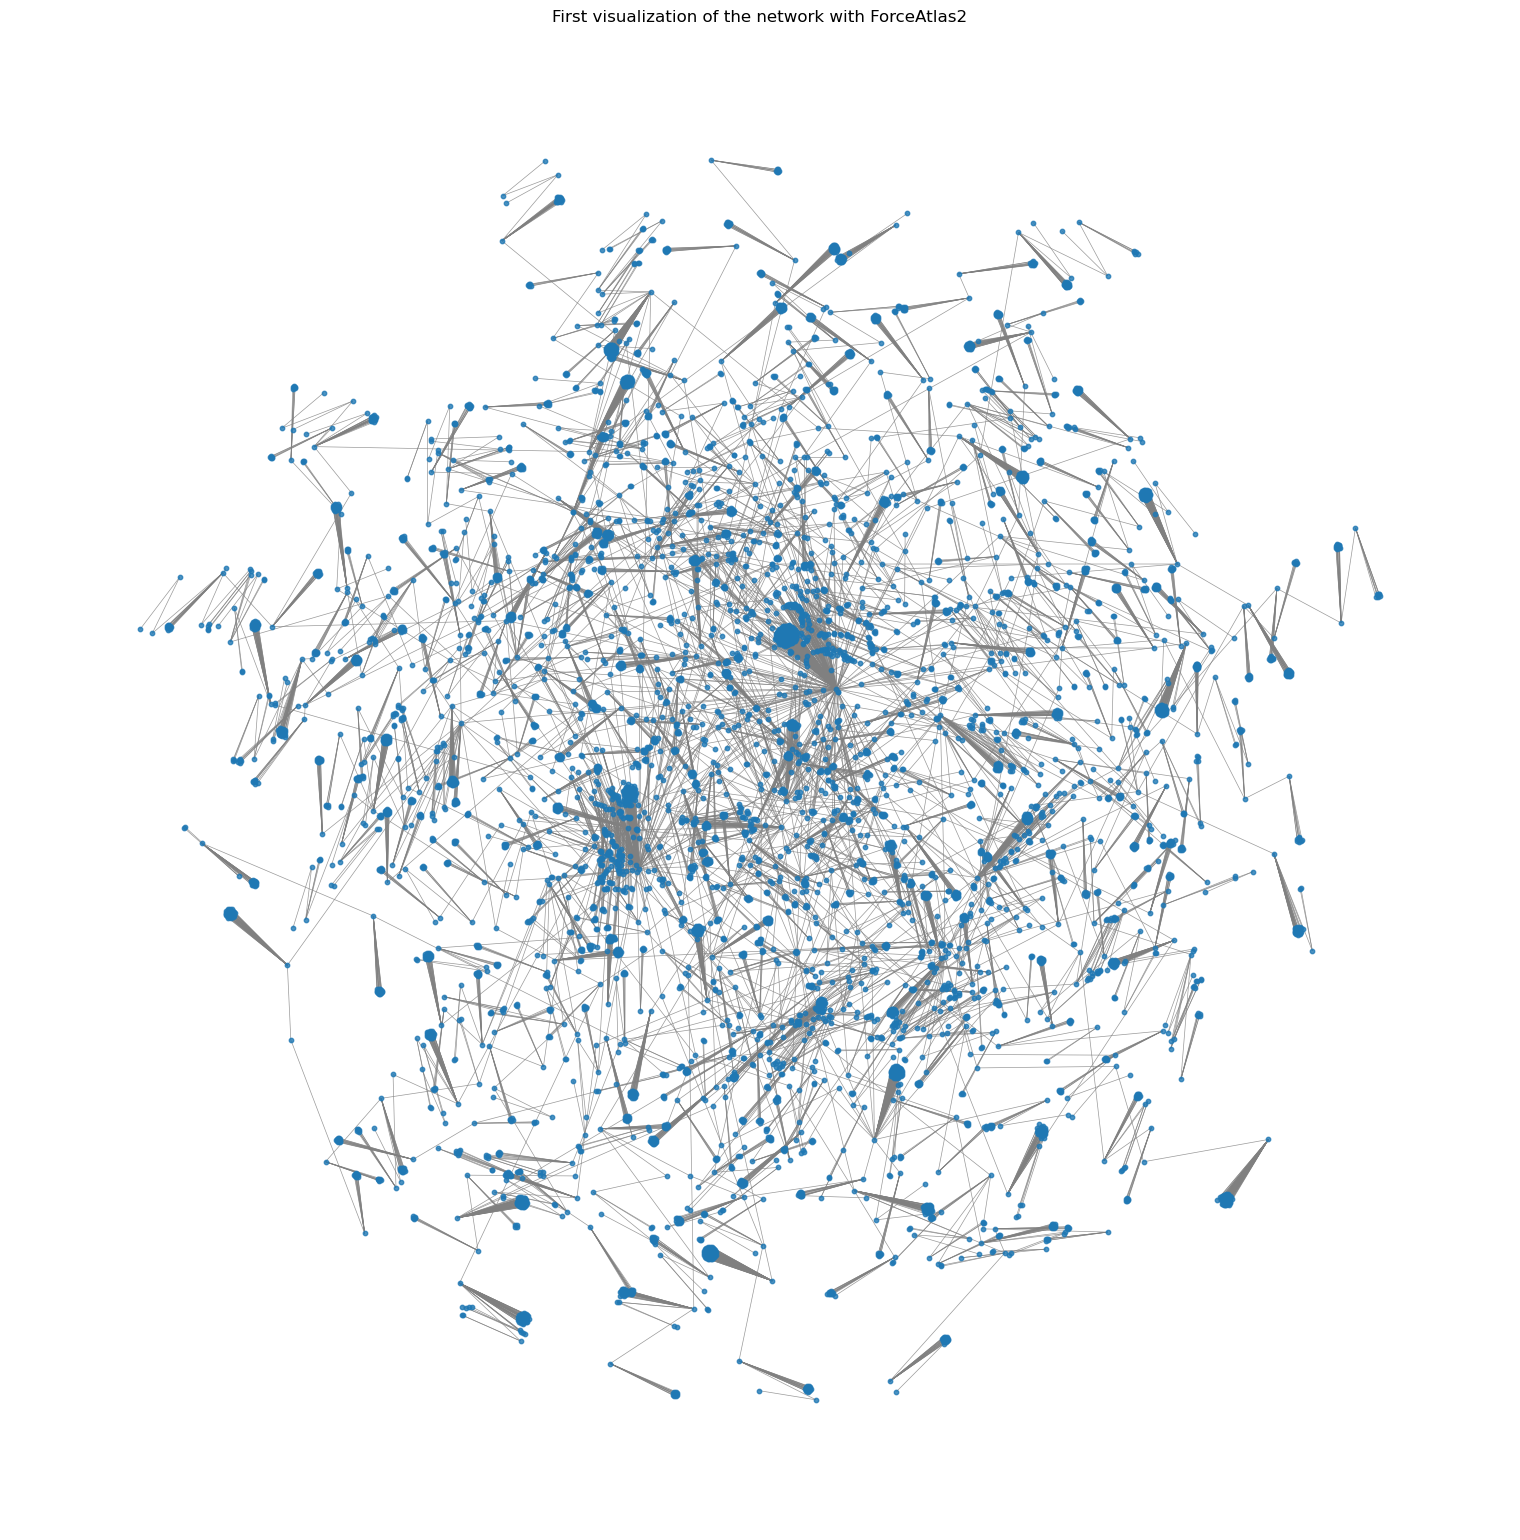

In [16]:
plt.figure(figsize=(15, 15))

nx.draw(
    G_und,
    pos=pose,
    node_size=10,
    alpha=0.8,
    edge_color='gray',
    width=0.5,
    with_labels=False
)

plt.title("First visualization of the network with ForceAtlas2")
plt.axis('off')
plt.show()

In [24]:
print(nx.average_shortest_path_length(G_und))

8.298217094182363


In [25]:
in_degree_sequence = sorted([d for d in G_filtered.in_degree()], key = (lambda x: x[1]), reverse=True)

out_degree_sequence = sorted([d for d in G_filtered.out_degree()], key = (lambda x: x[1]), reverse=True)

print(in_degree_sequence[0:50])
print(out_degree_sequence[0:50])

[('yaroslavvb', 76), ('keon', 66), ('damcclane', 61), ('Hvass-Labs', 60), ('ymfa', 59), ('cancan101', 57), ('konnerthg', 57), ('Elmit2015', 56), ('mohamedmansour', 51), ('KrishnaveniTK', 50), ('jiapei100', 49), ('guppy57', 49), ('GF-Huang', 48), ('dynamicwebpaige', 47), ('natsukium', 47), ('alanpurple', 46), ('mrry', 41), ('Overdrivr', 40), ('tfboyd', 40), ('reinaldocmendes', 40), ('JoanRessing', 38), ('ppwwyyxx', 37), ('deepakrai9185720', 37), ('kirk86', 36), ('feranick', 36), ('doncat99', 35), ('Huxwell', 35), ('gian1312', 33), ('Mainak431', 32), ('FabianShallari', 31), ('ido-tera-group', 31), ('dineshgit', 31), ('suharshs', 31), ('kettenfett', 31), ('frogtd', 31), ('LoveMIssY', 31), ('vladfi1', 30), ('zzeniale', 30), ('epivbg', 30), ('andreas-eberle', 29), ('fayeshine', 29), ('adam-hartshorne', 29), ('ushnish', 28), ('sudhirshahu51', 28), ('jinsu-kim', 28), ('Krishnarohith10', 28), ('JuanVargas', 28), ('damienpontifex', 27), ('michaelmyc', 27), ('lothrop', 27)]
[('bhack', 296), ('eb